# 1. Model Development Overview

Stage 6 compares five untuned model families across ten pairings with Notebook 03 preprocessing. The aim is a justified shortlist for Notebook 05, not final model selection. All fitting uses the 1,434-row development set and refits the complete pipeline inside folds. The locked holdout is reserved for Notebook 05. This notebook performs no tuning, weighting, resampling, holdout evaluation, or final-model export.

# 2. Environment and Reproducibility

Record library versions and use seed 42 where supported. Bound model parallelism to avoid nested work. Estimators stay at baseline settings except for reproducibility, multiclass operation, convergence, or quiet/safe execution.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # Bound joblib workers for stable n_jobs=-1 behavior.
from IPython.display import display


In [2]:
import sys, json, time, warnings, platform
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
 classification_report, confusion_matrix, f1_score, log_loss, matthews_corrcoef,
 precision_recall_curve, precision_score, recall_score, precision_recall_fscore_support)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
RANDOM_STATE=42
CLASS_ORDER=["Functional","Partially functional","Abandoned or not functional"]
CLASS_TO_ID={name:i for i,name in enumerate(CLASS_ORDER)}
ID_TO_CLASS={i:name for name,i in CLASS_TO_ID.items()}
CLASS_IDS=np.arange(3)
print({"python":platform.python_version(),"pandas":pd.__version__,"numpy":np.__version__,
 "sklearn":sklearn.__version__,"xgboost":__import__("xgboost").__version__,
 "catboost":__import__("catboost").__version__})

{'python': '3.11.9', 'pandas': '2.2.3', 'numpy': '2.3.5', 'sklearn': '1.8.0', 'xgboost': '3.2.0', 'catboost': '1.2.10'}


# 3. Load Development Data

Only `X_train_raw.csv` and `y_train.csv` are read. Assertions protect the 1,434 × 32 development boundary and expected three labels.

In [3]:
DATA_DIR=Path("../data/processed/modern")
X_train=pd.read_csv(DATA_DIR/"X_train_raw.csv")
y_text=pd.read_csv(DATA_DIR/"y_train.csv")["functional3"]
assert X_train.shape==(1434,32) and len(y_text)==1434
assert "functional3" not in X_train and set(y_text.unique())==set(CLASS_ORDER)
y=y_text.map(CLASS_TO_ID).astype(int)
assert not y.isna().any()
display(y_text.value_counts().reindex(CLASS_ORDER).rename("count").to_frame())

,count
functional3,
Functional,1066
Partially functional,126
Abandoned or not functional,242


# 4. Reconstruct Notebook 03 Preprocessing

Notebook 03 is authoritative. The selected definition cells are reproduced below; no notebook is executed and no handoff files are rewritten. All learned transformations remain inside each fold.

In [4]:
class FixedDataCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned = X.copy()
        cleaned["wc_savings_wp"] = cleaned["wc_savings_wp"].replace({999.0: np.nan, 888.0: np.nan})
        return cleaned

_clean_preview = FixedDataCleaner().fit_transform(X_train)
print("Training sentinel counts before:", X_train["wc_savings_wp"].isin([999, 888]).sum())
print("Training sentinel counts after:", _clean_preview["wc_savings_wp"].isin([999, 888]).sum())
assert X_train["wc_savings_wp"].equals(X_train.copy()["wc_savings_wp"])

class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Adds engineered features. All fitted statistics come from the data passed
    # to .fit() only (i.e. the training split, when used inside the full pipeline).

    def fit(self, X, y=None):
        wp_age_train = X["wp_age"].astype(float)
        self.wp_age_median_ = wp_age_train.median()
        wp_age_filled = wp_age_train.fillna(self.wp_age_median_)
        q1, q2 = wp_age_filled.quantile([1 / 3, 2 / 3])
        self.wp_age_edges_ = (float(q1), float(q2))
        return self

    def transform(self, X):
        X = X.copy()

        # people_per_household: guard against division by zero / missing inputs
        qtyhh_safe = X["qtyhh_wp"].replace(0, np.nan)
        X["people_per_household"] = X["qtypeople_wp"] / qtyhh_safe

        # was_rehabilitated: clean 0/1/NaN mirror of rehabyn
        X["was_rehabilitated"] = X["rehabyn"].map({"Yes": 1, "No": 0})

        # has_management_committee: Water committee vs. everything else
        X["has_management_committee"] = (X["whomanage_wp"] == "Water committee").astype(int)

        # rehab_age: preserve structural meaning (fill 0 + explicit indicator)
        X["rehab_age_missing"] = X["rehab_age"].isna().astype(int)
        X["rehab_age"] = X["rehab_age"].fillna(0)

        # pop_1000: separate missing-indicator (kept apart from the log1p branch)
        X["pop_1000_missing"] = X["pop_1000"].isna().astype(int)

        # wp_age_group: bin using edges fitted on the training split only
        wp_age_filled = X["wp_age"].fillna(self.wp_age_median_)
        q1, q2 = self.wp_age_edges_
        X["wp_age_group"] = pd.cut(
            wp_age_filled,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["New", "Established", "Old"],
        ).astype(str)

        return X


# Quick sanity preview, fit on the training split only
_fe_preview = FeatureEngineer().fit(X_train)
print(f"wp_age_group bin edges (fitted on X_train only): {_fe_preview.wp_age_edges_}")
_preview_out = _fe_preview.transform(X_train.head())
_preview_out[[
    "wp_age", "wp_age_group", "rehabyn", "was_rehabilitated",
    "whomanage_wp", "has_management_committee",
    "qtypeople_wp", "qtyhh_wp", "people_per_household",
    "rehab_age", "rehab_age_missing", "pop_1000", "pop_1000_missing",
]]

CAT_NOT_APPLICABLE_COLS = ["pumptype", "drillmethod", "piped_source", "piped_pump"]
CAT_UNKNOWN_RAW_COLS = [
    "country", "admin1", "wptype", "whomanage_wp", "rehabyn", "season",
    "cwfunded_wp", "wc_present_wp", "paytocollect_wp", "lockedfullday_wp",
]
ORDINAL_COLS = ["wc_admin_index_wp", "wc_finance_index_wp", "wc_mgmt_index_wp", "wc_maint_index_wp"]
ORDINAL_CATEGORY_ORDER = ["Inadequate", "Minimum", "Moderate", "Advanced", "Missing"]
RARE_MIN_FREQUENCY_CANDIDATES = [5, 10, 20]

def remap_ordinal_missing_code(codes):
    return np.where(codes == 4, -1, codes)

print("Structural categorical:", CAT_NOT_APPLICABLE_COLS)
print("Unknown categorical:", CAT_UNKNOWN_RAW_COLS)
print("Ordinal:", ORDINAL_COLS)

NUM_LOG_CANDIDATES = ["wp_age", "qtypeople_wp", "qtyhh_wp", "pop_1000"]
NUM_OTHER = ["elevation_wp", "latitude_wp", "longitude_wp", "rehab_age"]
NUM_WITH_INDICATOR = [
    "annual_rain", "wpqty_wp", "qtyhh_c_wp", "improved_wponly_wp",
    "wc_savings_wp", "pumpstrokes",
]
SEMANTIC_FLAGS = ["rehab_age_missing", "pop_1000_missing"]
OPTIONAL_NUM_WITH_INDICATOR = ["people_per_household", "was_rehabilitated"]
OPTIONAL_FLAGS = ["has_management_committee"]
OPTIONAL_CATEGORICAL = ["wp_age_group"]
print("Log candidates:", NUM_LOG_CANDIDATES)

RAW_PREDICTOR_COLS = (
    CAT_NOT_APPLICABLE_COLS + CAT_UNKNOWN_RAW_COLS + ORDINAL_COLS
    + NUM_LOG_CANDIDATES + NUM_OTHER + NUM_WITH_INDICATOR
)
assert len(RAW_PREDICTOR_COLS) == 32
assert len(set(RAW_PREDICTOR_COLS)) == 32
assert set(RAW_PREDICTOR_COLS) == set(X_train.columns)
print("Approved raw predictor count:", len(RAW_PREDICTOR_COLS))

class CategoricalStringifier(BaseEstimator, TransformerMixin):
    """Keep imputed nominal columns as CatBoost-safe Python strings."""

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        output = X.copy()
        for column in output.columns:
            output[column] = output[column].astype(str)
        return output

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray(input_features, dtype=object)


def catboost_categorical_feature_names(include_optional_engineered_features):
    """Exact transformed DataFrame names, in ColumnTransformer order."""
    unknown_cols = CAT_UNKNOWN_RAW_COLS + (OPTIONAL_CATEGORICAL if include_optional_engineered_features else [])
    return ([f"cat_not_applicable__{column}" for column in CAT_NOT_APPLICABLE_COLS]
            + [f"cat_unknown__{column}" for column in unknown_cols])


def build_catboost_native_pipeline(include_optional_engineered_features):
    """Reuse the existing tree numeric/ordinal branches; replace only nominal OHE."""
    tree_reference = build_preprocessing_pipeline(
        "tree_boosting", include_optional_engineered_features,
        rare_min_frequency=10, use_log_transform=False, scale_numeric=False,
    )
    tree_branches = tree_reference.named_steps["preprocessing"].transformers
    native_branches = []
    for name, transformer, columns in tree_branches:
        if name in {"cat_not_applicable", "cat_unknown"}:
            fill = "Not applicable" if name == "cat_not_applicable" else "Unknown"
            transformer = Pipeline([
                ("impute", SimpleImputer(strategy="constant", fill_value=fill)),
                ("to_strings", CategoricalStringifier()),
            ])
        native_branches.append((name, transformer, columns))
    preprocessor = ColumnTransformer(
        native_branches, remainder="drop", verbose_feature_names_out=True,
    )
    preprocessor.set_output(transform="pandas")
    return Pipeline([
        ("fixed_cleaning", FixedDataCleaner()),
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessor),
    ])


def build_preprocessing_pipeline(model_family, include_optional_engineered_features,
                                 rare_min_frequency=10, use_log_transform=None,
                                 scale_numeric=None):
    if model_family == "catboost_native":
        # The existing builder default is 10 for OHE families. It is ignored here;
        # explicit alternative rare thresholds are invalid for native categories.
        if rare_min_frequency not in (None, 10):
            raise ValueError("rare_min_frequency is not applicable to catboost_native")
        if use_log_transform not in (None, False) or scale_numeric not in (None, False):
            raise ValueError("CatBoost-native baseline does not use log transforms or scaling")
        return build_catboost_native_pipeline(include_optional_engineered_features)
    if model_family not in {"scale_sensitive", "tree_boosting"}:
        raise ValueError("model_family must be scale_sensitive, tree_boosting, or catboost_native")
    if not isinstance(rare_min_frequency, int) or rare_min_frequency < 1:
        raise ValueError("rare_min_frequency must be a positive integer")
    if use_log_transform is None:
        use_log_transform = model_family == "scale_sensitive"
    if scale_numeric is None:
        scale_numeric = model_family == "scale_sensitive"

    def categorical_branch(fill_value):
        return Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=fill_value)),
            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                      min_frequency=rare_min_frequency, sparse_output=False)),
        ])

    ordinal_branch = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("ordinal", OrdinalEncoder(categories=[ORDINAL_CATEGORY_ORDER] * len(ORDINAL_COLS))),
        ("remap_missing", FunctionTransformer(remap_ordinal_missing_code,
                                                 feature_names_out="one-to-one")),
    ])
    log_steps = [("impute", SimpleImputer(strategy="median"))]
    if use_log_transform:
        log_steps.append(("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")))
    if scale_numeric:
        log_steps.append(("scale", StandardScaler()))
    other_steps = [("impute", SimpleImputer(strategy="median"))]
    indicator_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        other_steps.append(("scale", StandardScaler()))
        indicator_steps.append(("scale", StandardScaler()))

    unknown_cols = CAT_UNKNOWN_RAW_COLS + (OPTIONAL_CATEGORICAL if include_optional_engineered_features else [])
    indicator_cols = NUM_WITH_INDICATOR + (OPTIONAL_NUM_WITH_INDICATOR if include_optional_engineered_features else [])
    flags = SEMANTIC_FLAGS + (OPTIONAL_FLAGS if include_optional_engineered_features else [])
    preprocessor = ColumnTransformer([
        ("cat_not_applicable", categorical_branch("Not applicable"), CAT_NOT_APPLICABLE_COLS),
        ("cat_unknown", categorical_branch("Unknown"), unknown_cols),
        ("ordinal_wc_index", ordinal_branch, ORDINAL_COLS),
        ("num_skew", Pipeline(log_steps), NUM_LOG_CANDIDATES),
        ("num_other", Pipeline(other_steps), NUM_OTHER),
        ("num_indicator", Pipeline(indicator_steps), indicator_cols),
        ("semantic_flags", "passthrough", flags),
    ], remainder="drop", verbose_feature_names_out=True)
    preprocessor.set_output(transform="pandas")
    return Pipeline([
        ("fixed_cleaning", FixedDataCleaner()),
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessor),
    ])

VARIANTS = {
    "scaled_base": dict(model_family="scale_sensitive", include_optional_engineered_features=False,
                        rare_min_frequency=10, use_log_transform=True, scale_numeric=True),
    "scaled_engineered": dict(model_family="scale_sensitive", include_optional_engineered_features=True,
                              rare_min_frequency=10, use_log_transform=True, scale_numeric=True),
    "tree_base": dict(model_family="tree_boosting", include_optional_engineered_features=False,
                      rare_min_frequency=10, use_log_transform=False, scale_numeric=False),
    "tree_engineered": dict(model_family="tree_boosting", include_optional_engineered_features=True,
                            rare_min_frequency=10, use_log_transform=False, scale_numeric=False),
    "catboost_native_base": dict(model_family="catboost_native",
                                 include_optional_engineered_features=False,
                                 rare_min_frequency=None, use_log_transform=False,
                                 scale_numeric=False, one_hot_encode=False,
                                 native_categorical_handling=True,
                                 categorical_features=catboost_categorical_feature_names(False)),
    "catboost_native_engineered": dict(model_family="catboost_native",
                                       include_optional_engineered_features=True,
                                       rare_min_frequency=None, use_log_transform=False,
                                       scale_numeric=False, one_hot_encode=False,
                                       native_categorical_handling=True,
                                       categorical_features=catboost_categorical_feature_names(True)),
}
candidate_pipelines = {
    name: build_preprocessing_pipeline(**{
        key: value for key, value in config.items()
        if key not in {"one_hot_encode", "native_categorical_handling", "categorical_features"}
    })
    for name, config in VARIANTS.items()
}
print("Unfitted candidate variants:", list(candidate_pipelines))

Training sentinel counts before: 66
Training sentinel counts after: 0
wp_age_group bin edges (fitted on X_train only): (2.0, 4.0)
Structural categorical: ['pumptype', 'drillmethod', 'piped_source', 'piped_pump']
Unknown categorical: ['country', 'admin1', 'wptype', 'whomanage_wp', 'rehabyn', 'season', 'cwfunded_wp', 'wc_present_wp', 'paytocollect_wp', 'lockedfullday_wp']
Ordinal: ['wc_admin_index_wp', 'wc_finance_index_wp', 'wc_mgmt_index_wp', 'wc_maint_index_wp']
Log candidates: ['wp_age', 'qtypeople_wp', 'qtyhh_wp', 'pop_1000']
Approved raw predictor count: 32
Unfitted candidate variants: ['scaled_base', 'scaled_engineered', 'tree_base', 'tree_engineered', 'catboost_native_base', 'catboost_native_engineered']


# 5. Preprocessing Parity Checks

Fit all six preprocessors on development data only before any model. Full-data feature widths are asserted; one-hot fold widths may vary legitimately because category frequencies are learned per fold.

In [5]:
EXPECTED_WIDTHS={"scaled_base":102,"scaled_engineered":110,"tree_base":102,
 "tree_engineered":110,"catboost_native_base":40,"catboost_native_engineered":46}
assert X_train.shape==(1434,32) and set(X_train.columns)==set(RAW_PREDICTOR_COLS)
assert list(VARIANTS)==list(EXPECTED_WIDTHS)
parity_outputs={}; parity_rows=[]
for name,width in EXPECTED_WIDTHS.items():
 out=clone(candidate_pipelines[name]).fit_transform(X_train)
 assert isinstance(out,pd.DataFrame) and out.shape==(1434,width),(name,out.shape)
 assert out.columns.is_unique and out.notna().all().all()
 if name.startswith("catboost_native"):
  cats=VARIANTS[name]["categorical_features"]
  assert all(c in out for c in cats)
  assert all(out[c].map(lambda v:isinstance(v,str)).all() for c in cats)
  assert np.isfinite(out.drop(columns=cats).to_numpy(dtype=float)).all()
 else: assert np.isfinite(out.to_numpy(dtype=float)).all()
 assert isinstance(clone(candidate_pipelines[name]),Pipeline)
 parity_outputs[name]=out;parity_rows.append({"variant":name,"shape":out.shape,"status":"PASS"})
parity_summary=pd.DataFrame(parity_rows);display(parity_summary)
assert parity_summary.status.eq("PASS").all()
print("Six-candidate preprocessing parity passed before model fitting.")

,variant,shape,status
0,scaled_base,"(1434, 102)",PASS
1,scaled_engineered,"(1434, 110)",PASS
2,tree_base,"(1434, 102)",PASS
3,tree_engineered,"(1434, 110)",PASS
4,catboost_native_base,"(1434, 40)",PASS
5,catboost_native_engineered,"(1434, 46)",PASS


Six-candidate preprocessing parity passed before model fitting.


# 6. Target Label Representation

Integer IDs support consistent library APIs. They are nominal labels and imply no ordering. Reports map them back to class names. Regression metrics such as RMSE, MSE, MAE, and R² are not used.

In [6]:
assert CLASS_TO_ID=={"Functional":0,"Partially functional":1,"Abandoned or not functional":2}
print("Nominal class IDs:",CLASS_TO_ID)

Nominal class IDs: {'Functional': 0, 'Partially functional': 1, 'Abandoned or not functional': 2}


# 7. Model Selection Rationale

Logistic Regression is a linear probability baseline; Random Forest is a bagged nonlinear ensemble; HistGradientBoosting is a modern sklearn histogram learner; XGBoost provides a separate boosting implementation; CatBoost tests native categorical processing. No family is presumed best.

# 8. Baseline Model Definitions

Use ordinary baseline settings, without class weights. XGBoost and CatBoost optimization is deferred to Notebook 05.
The measured default CatBoost repeated-CV run took several minutes for its first configuration; the 250-iteration controlled run averaged roughly 18 seconds per fold, before OOF and country diagnostics. A fixed 100-iteration cap is therefore used for both CatBoost variants and all diagnostics as a computational baseline control. It was chosen only to make the required resampling-free CV run practical; it was not selected using scores. Notebook 05 may tune iterations.


In [7]:
def make_classifier(family):
 if family=="Logistic Regression":return LogisticRegression(max_iter=2000,solver="lbfgs")
 if family=="Random Forest":return RandomForestClassifier(random_state=42,n_jobs=-1)
 if family=="HistGradientBoosting":return HistGradientBoostingClassifier(random_state=42)
 if family=="XGBoost":return XGBClassifier(objective="multi:softprob",eval_metric="mlogloss",random_state=42,verbosity=0,n_jobs=4)
 if family=="CatBoost":return CatBoostClassifier(iterations=100,loss_function="MultiClass",random_seed=42,verbose=False,allow_writing_files=False,thread_count=4)
 raise ValueError(family)
MODEL_RATIONALE={"Logistic Regression":"Interpretable linear probabilistic reference.",
 "Random Forest":"Bagging and nonlinear interactions.","HistGradientBoosting":"Efficient sklearn-native histogram boosting.",
 "XGBoost":"Independent gradient-boosting baseline.","CatBoost":"Boosting with native categorical handling."}

# 9. Model and Preprocessing Configurations

Exactly ten pairings use the appropriate Notebook 03 family. CatBoost uses native categorical columns; Logistic Regression uses scaled inputs.

In [8]:
CONFIGS=[
 {"configuration":"LR Base","model_family":"Logistic Regression","preprocessing_variant":"scaled_base"},
 {"configuration":"LR Engineered","model_family":"Logistic Regression","preprocessing_variant":"scaled_engineered"},
 {"configuration":"RF Base","model_family":"Random Forest","preprocessing_variant":"tree_base"},
 {"configuration":"RF Engineered","model_family":"Random Forest","preprocessing_variant":"tree_engineered"},
 {"configuration":"HistGB Base","model_family":"HistGradientBoosting","preprocessing_variant":"tree_base"},
 {"configuration":"HistGB Engineered","model_family":"HistGradientBoosting","preprocessing_variant":"tree_engineered"},
 {"configuration":"XGBoost Base","model_family":"XGBoost","preprocessing_variant":"tree_base"},
 {"configuration":"XGBoost Engineered","model_family":"XGBoost","preprocessing_variant":"tree_engineered"},
 {"configuration":"CatBoost Base","model_family":"CatBoost","preprocessing_variant":"catboost_native_base"},
 {"configuration":"CatBoost Engineered","model_family":"CatBoost","preprocessing_variant":"catboost_native_engineered"}]
assert len(CONFIGS)==10
def make_pipeline(config):
 return Pipeline([("preprocessing",clone(candidate_pipelines[config["preprocessing_variant"]])),
                  ("classifier",make_classifier(config["model_family"]))])
display(pd.DataFrame(CONFIGS))

,configuration,model_family,preprocessing_variant
0,LR Base,Logistic Regression,scaled_base
1,LR Engineered,Logistic Regression,scaled_engineered
2,RF Base,Random Forest,tree_base
3,RF Engineered,Random Forest,tree_engineered
4,HistGB Base,HistGradientBoosting,tree_base
5,HistGB Engineered,HistGradientBoosting,tree_engineered
6,XGBoost Base,XGBoost,tree_base
7,XGBoost Engineered,XGBoost,tree_engineered
8,CatBoost Base,CatBoost,catboost_native_base
9,CatBoost Engineered,CatBoost,catboost_native_engineered


# 10. Validation Strategy

Primary ranking uses RepeatedStratifiedKFold (5 folds × 3 repeats, 15 evaluations/configuration). Stratification preserves representation of the 126 Partially functional development rows; five folds provide more minority-class validation support than ten folds, and repeats reduce dependence on one split. A separate fixed five-fold StratifiedKFold creates one OOF prediction per row.

In [9]:
repeated_cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=42)
oof_cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
repeated_splits=list(repeated_cv.split(X_train,y));oof_splits=list(oof_cv.split(X_train,y))
assert len(repeated_splits)==15 and len(oof_splits)==5

# 11. Evaluation Metrics

Macro-F1 is primary because it gives each class equal importance. Supporting metrics are Balanced Accuracy, Macro Recall/Precision, MCC, Weighted F1, Accuracy, multiclass Log Loss, and one-vs-rest Average Precision. MCC complements Macro-F1 by using the full confusion structure. Log Loss evaluates probability quality (lower is better). AP summarizes the precision-recall curve and is reported per class.

In [10]:
def align_probabilities(estimator,raw):
 aligned=np.zeros((len(raw),3),dtype=float)
 for j,class_id in enumerate(np.asarray(estimator.classes_,dtype=int)):
  if class_id not in CLASS_IDS:raise ValueError(f"Unexpected class ID {class_id}")
  aligned[:,class_id]=raw[:,j]
 row_sums=aligned.sum(axis=1,keepdims=True)
 if np.any(row_sums<=0):raise ValueError("A predicted probability row has no positive mass")
 aligned=aligned/row_sums
 assert aligned.shape==(len(raw),3) and np.allclose(aligned.sum(axis=1),1,atol=1e-12)
 return aligned

def calculate_metrics(truth,pred,prob):
 precision,recall,f1,_=precision_recall_fscore_support(truth,pred,labels=CLASS_IDS,zero_division=0)
 ap=np.array([average_precision_score((truth==c).astype(int),prob[:,c]) for c in CLASS_IDS])
 return {"macro_f1":f1_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "balanced_accuracy":balanced_accuracy_score(truth,pred),
  "macro_recall":recall_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "macro_precision":precision_score(truth,pred,labels=CLASS_IDS,average="macro",zero_division=0),
  "mcc":matthews_corrcoef(truth,pred),
  "weighted_f1":f1_score(truth,pred,labels=CLASS_IDS,average="weighted",zero_division=0),
  "accuracy":accuracy_score(truth,pred),"log_loss":log_loss(truth,prob,labels=CLASS_IDS),
  "macro_ap":float(ap.mean()),"class_precision":precision,"class_recall":recall,"class_f1":f1,"class_ap":ap}

# 12. Repeated-CV Baseline Evaluation

The manual evaluator clones the complete pipeline per fold, fits only the fold's training rows, and records training Macro-F1, validation metrics, fit time, repeat/fold identity, and warnings. No preprocessing statistic is learned globally for CV.

In [11]:
fold_records=[];warning_records=[]
def evaluate_repeated_cv(config):
 rows=[]
 for split_no,(tr,va) in enumerate(repeated_splits,1):
  repeat=(split_no-1)//5+1;fold=(split_no-1)%5+1
  pipe=make_pipeline(config);fit_kwargs={}
  if config["model_family"]=="CatBoost":fit_kwargs["classifier__cat_features"]=VARIANTS[config["preprocessing_variant"]]["categorical_features"]
  with warnings.catch_warnings(record=True) as caught:
   warnings.simplefilter("always");start=time.perf_counter()
   pipe.fit(X_train.iloc[tr],y.iloc[tr],**fit_kwargs);fit_seconds=time.perf_counter()-start
   train_pred=pipe.predict(X_train.iloc[tr]).astype(int).reshape(-1)
   valid_pred=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1).reshape(-1)
   valid_prob=align_probabilities(pipe.named_steps["classifier"],pipe.predict_proba(X_train.iloc[va]))
  for w in caught:warning_records.append({"configuration":config["configuration"],"repeat":repeat,"fold":fold,"category":w.category.__name__,"message":str(w.message)})
  train_macro=f1_score(y.iloc[tr],train_pred,labels=CLASS_IDS,average="macro",zero_division=0)
  metric=calculate_metrics(y.iloc[va].to_numpy(),valid_pred,valid_prob)
  rows.append({"configuration":config["configuration"],"model_family":config["model_family"],
   "preprocessing_variant":config["preprocessing_variant"],"repeat":repeat,"fold":fold,
   "train_macro_f1":train_macro,"train_cv_gap":train_macro-metric["macro_f1"],
   "fit_seconds":fit_seconds,**{k:v for k,v in metric.items() if np.isscalar(v)}})
 return rows
for cfg in CONFIGS:
 print("Evaluating",cfg["configuration"],flush=True);fold_records.extend(evaluate_repeated_cv(cfg))
fold_results=pd.DataFrame(fold_records)
assert len(fold_results)==150 and fold_results.groupby("configuration").size().eq(15).all()

Evaluating LR Base
Evaluating LR Engineered
Evaluating RF Base
Evaluating RF Engineered
Evaluating HistGB Base
Evaluating HistGB Engineered
Evaluating XGBoost Base
Evaluating XGBoost Engineered
Evaluating CatBoost Base
Evaluating CatBoost Engineered


# 13. Baseline Model Comparison

Means and standard deviations summarize repeated folds; display sorts by primary Macro-F1. Supporting metrics reveal tradeoffs and are not combined into an arbitrary score.

In [12]:
METRICS=["macro_f1","balanced_accuracy","macro_recall","macro_precision","mcc","weighted_f1","accuracy","log_loss","macro_ap","train_macro_f1","train_cv_gap","fit_seconds"]
summary=[]
for cfg in CONFIGS:
 block=fold_results[fold_results.configuration==cfg["configuration"]]
 row={"configuration":cfg["configuration"],"model_family":cfg["model_family"],
      "preprocessing_variant":cfg["preprocessing_variant"],
      "engineered_features":VARIANTS[cfg["preprocessing_variant"]]["include_optional_engineered_features"]}
 for m in METRICS:
  row[f"mean_{m}"]=block[m].mean()
  if m=="macro_f1":row["sd_macro_f1"]=block[m].std(ddof=1)
 summary.append(row)
cv_summary=pd.DataFrame(summary).sort_values("mean_macro_f1",ascending=False).reset_index(drop=True)
display(cv_summary.round(4))

,configuration,model_family,preprocessing_variant,engineered_features,mean_macro_f1,sd_macro_f1,mean_balanced_accuracy,mean_macro_recall,mean_macro_precision,mean_mcc,mean_weighted_f1,mean_accuracy,mean_log_loss,mean_macro_ap,mean_train_macro_f1,mean_train_cv_gap,mean_fit_seconds
0,HistGB Base,HistGradientBoosting,tree_base,False,0.6953,0.0274,0.6720,0.6720,0.7503,0.6332,0.8467,0.8570,0.6678,0.7336,1.0000,0.3047,1.3287
1,XGBoost Base,XGBoost,tree_base,False,0.6891,0.0283,0.6627,0.6627,0.7524,0.6285,0.8445,0.8564,0.5202,0.7361,1.0000,0.3109,0.4677
2,HistGB Engineered,HistGradientBoosting,tree_engineered,True,0.6844,0.0256,0.6627,0.6627,0.7342,0.6197,0.8413,0.8522,0.7011,0.7329,1.0000,0.3156,1.5355
3,XGBoost Engineered,XGBoost,tree_engineered,True,0.6813,0.0267,0.6564,0.6564,0.7392,0.6224,0.8417,0.8540,0.5275,0.7363,1.0000,0.3187,0.4683
4,RF Base,Random Forest,tree_base,False,0.6689,0.0288,0.6388,0.6388,0.7510,0.6128,0.8368,0.8529,0.6504,0.7283,0.9996,0.3307,0.3294
5,RF Engineered,Random Forest,tree_engineered,True,0.6587,0.0394,0.6265,0.6265,0.7467,0.5966,0.8308,0.8480,0.6246,0.7283,0.9998,0.3411,0.2830
6,CatBoost Base,CatBoost,catboost_native_base,False,0.6251,0.0326,0.6003,0.6003,0.7120,0.5592,0.8151,0.8347,0.4539,0.7011,0.8343,0.2091,7.6584
7,CatBoost Engineered,CatBoost,catboost_native_engineered,True,0.6113,0.0304,0.5869,0.5869,0.6920,0.5398,0.8075,0.8280,0.4665,0.6957,0.8396,0.2283,7.8719
8,LR Engineered,Logistic Regression,scaled_engineered,True,0.6013,0.0402,0.5756,0.5756,0.6984,0.5492,0.8081,0.8345,0.4705,0.6848,0.6681,0.0667,0.3435
9,LR Base,Logistic Regression,scaled_base,False,0.5966,0.0412,0.5703,0.5703,0.6964,0.5449,0.8059,0.8333,0.4579,0.6885,0.6627,0.0660,0.3152


# 14. Fixed Five-Fold OOF Predictions

A separate five-fold pass creates exactly one OOF predicted class and probability vector per development row/configuration. These predictions drive per-class reports and confusion diagnostics. No observation is in the training data of the model that predicts it.

In [13]:
oof_records=[];class_records=[];oof_confusions={}
for cfg in CONFIGS:
 pred=np.full(len(y),-1,dtype=int);prob=np.full((len(y),3),np.nan);seen=np.zeros(len(y),dtype=int)
 for fold,(tr,va) in enumerate(oof_splits,1):
  pipe=make_pipeline(cfg);fit_kwargs={}
  if cfg["model_family"]=="CatBoost":fit_kwargs["classifier__cat_features"]=VARIANTS[cfg["preprocessing_variant"]]["categorical_features"]
  with warnings.catch_warnings(record=True) as caught:
   warnings.simplefilter("always");pipe.fit(X_train.iloc[tr],y.iloc[tr],**fit_kwargs)
   fold_pred=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1).reshape(-1)
   fold_prob=align_probabilities(pipe.named_steps["classifier"],pipe.predict_proba(X_train.iloc[va]))
  for w in caught:warning_records.append({"configuration":cfg["configuration"],"repeat":"OOF","fold":fold,"category":w.category.__name__,"message":str(w.message)})
  pred[va]=fold_pred;prob[va]=fold_prob;seen[va]+=1
 assert np.all(seen==1) and not np.isnan(prob).any() and np.allclose(prob.sum(axis=1),1,atol=1e-6)
 name=cfg["configuration"];oof_confusions[name]=confusion_matrix(y,pred,labels=CLASS_IDS)
 report=classification_report(y,pred,labels=CLASS_IDS,target_names=CLASS_ORDER,output_dict=True,zero_division=0)
 for cid,label in enumerate(CLASS_ORDER):
  row=report[label];ap=average_precision_score((y.to_numpy()==cid).astype(int),prob[:,cid])
  class_records.append({"configuration":name,"class":label,"support":int(row["support"]),"precision":row["precision"],"recall":row["recall"],"f1":row["f1-score"],"average_precision":ap})
 for i in range(len(y)):
  oof_records.append({"configuration":name,"row_index":i,"true_class":ID_TO_CLASS[int(y.iloc[i])],"predicted_class":ID_TO_CLASS[int(pred[i])],
   **{f"probability_{ID_TO_CLASS[c]}":float(prob[i,c]) for c in CLASS_IDS}})
oof_predictions=pd.DataFrame(oof_records);oof_class_metrics=pd.DataFrame(class_records)
assert len(oof_predictions)==14340 and oof_predictions.groupby("configuration").size().eq(1434).all()
display(oof_class_metrics.round(4))

,configuration,class,support,precision,recall,f1,average_precision
0,LR Base,Functional,1066,0.8442,0.9606,0.8986,0.9412
1,LR Base,Partially functional,126,0.3939,0.1032,0.1635,0.2762
2,LR Base,Abandoned or not functional,242,0.8085,0.6281,0.7070,0.7980
3,LR Engineered,Functional,1066,0.8492,0.9615,0.9019,0.9412
4,LR Engineered,Partially functional,126,0.4000,0.1111,0.1739,0.2751
5,LR Engineered,Abandoned or not functional,242,0.8177,0.6488,0.7235,0.7974
6,RF Base,Functional,1066,0.8761,0.9550,0.9138,0.9515
7,RF Base,Partially functional,126,0.5273,0.2302,0.3204,0.3695
8,RF Base,Abandoned or not functional,242,0.7880,0.7066,0.7451,0.8343
9,RF Engineered,Functional,1066,0.8723,0.9550,0.9118,0.9525


# 15. Per-Class and Minority-Class Evaluation

OOF class-level Precision, Recall, F1, support, and one-vs-rest AP are reported for every configuration. The Partially functional class receives explicit comparison alongside the Abandoned/not functional class.

In [14]:
minority=(oof_class_metrics[oof_class_metrics["class"].isin(["Partially functional","Abandoned or not functional"])]
 .pivot(index="configuration",columns="class",values=["precision","recall","f1","average_precision"]))
minority.columns=[f"{metric}_{label}" for metric,label in minority.columns]
minority=minority.reset_index();display(minority.round(4))

,configuration,precision_Abandoned or not functional,precision_Partially functional,recall_Abandoned or not functional,recall_Partially functional,f1_Abandoned or not functional,f1_Partially functional,average_precision_Abandoned or not functional,average_precision_Partially functional
0,CatBoost Base,0.7327,0.4364,0.6570,0.1905,0.6928,0.2652,0.7947,0.3090
1,CatBoost Engineered,0.7183,0.4783,0.6322,0.1746,0.6725,0.2558,0.7928,0.3017
2,HistGB Base,0.7890,0.5000,0.7727,0.2857,0.7808,0.3636,0.8555,0.3855
3,HistGB Engineered,0.7957,0.5000,0.7727,0.2540,0.7841,0.3368,0.8450,0.3651
4,LR Base,0.8085,0.3939,0.6281,0.1032,0.7070,0.1635,0.7980,0.2762
5,LR Engineered,0.8177,0.4000,0.6488,0.1111,0.7235,0.1739,0.7974,0.2751
6,RF Base,0.7880,0.5273,0.7066,0.2302,0.7451,0.3204,0.8343,0.3695
7,RF Engineered,0.7820,0.5179,0.6818,0.2302,0.7285,0.3187,0.8288,0.3659
8,XGBoost Base,0.7904,0.5667,0.7479,0.2698,0.7686,0.3656,0.8519,0.3799
9,XGBoost Engineered,0.7913,0.5075,0.7521,0.2698,0.7712,0.3523,0.8454,0.3635


# 16. Family Winners and Notebook 05 Shortlist

Within each family, choose by repeated-CV Macro-F1. If base and engineered means differ by no more than 0.005, resolve the practical tie in this order: Balanced Accuracy, Partial F1, Partial Recall, MCC, then lower Macro-F1 SD. No composite score is used. The top three family winners form an optimization shortlist, not a final model.

In [15]:
oof_by={}
for cfg in CONFIGS:
 block=oof_class_metrics[oof_class_metrics.configuration==cfg["configuration"]].set_index("class")
 oof_by[cfg["configuration"]]={"partial_precision":float(block.loc["Partially functional","precision"]),
  "partial_recall":float(block.loc["Partially functional","recall"]),"partial_f1":float(block.loc["Partially functional","f1"]),
  "partial_ap":float(block.loc["Partially functional","average_precision"]),
  "abandoned_recall":float(block.loc["Abandoned or not functional","recall"]),
  "abandoned_f1":float(block.loc["Abandoned or not functional","f1"]),
  "abandoned_ap":float(block.loc["Abandoned or not functional","average_precision"])}

def pick_variant(block, class_metrics=None):
 class_metrics=oof_by if class_metrics is None else class_metrics
 ordered=block.sort_values("mean_macro_f1",ascending=False)
 if len(ordered)>1 and ordered.iloc[0].mean_macro_f1-ordered.iloc[1].mean_macro_f1<=.005:
  tied=ordered.copy()
  for col in ["partial_f1","partial_recall"]:tied[col]=tied.configuration.map(lambda n:class_metrics[n][col])
  return tied.sort_values(["mean_balanced_accuracy","partial_f1","partial_recall","mean_mcc","sd_macro_f1"],ascending=[False,False,False,False,True]).iloc[0]
 return ordered.iloc[0]
# Synthetic decision checks exercise selection only; they do not enter any model results.
example_metrics={"Candidate A":{"partial_f1":.50,"partial_recall":.45},
                 "Candidate B":{"partial_f1":.30,"partial_recall":.25}}
example=pd.DataFrame([
 {"configuration":"Candidate A","mean_macro_f1":.600,"mean_balanced_accuracy":.700,"mean_mcc":.55,"sd_macro_f1":.03},
 {"configuration":"Candidate B","mean_macro_f1":.603,"mean_balanced_accuracy":.650,"mean_mcc":.50,"sd_macro_f1":.02},
])
assert pick_variant(example,example_metrics).configuration=="Candidate A", "Practical tie must use Balanced Accuracy first"
non_tie=example.copy()
non_tie.loc[non_tie.configuration=="Candidate B","mean_macro_f1"]=.607
assert pick_variant(non_tie,example_metrics).configuration=="Candidate B", "Outside practical tie, higher Macro-F1 must win"
print("PICK_VARIANT LOGIC CHECK: PASS")
winner_rows=[]
for family,block in cv_summary.groupby("model_family",sort=False):
 w=pick_variant(block);m=oof_by[w.configuration]
 winner_rows.append({"model_family":family,"configuration":w.configuration,"preprocessing_variant":w.preprocessing_variant,
  "mean_macro_f1":w.mean_macro_f1,"sd_macro_f1":w.sd_macro_f1,"balanced_accuracy":w.mean_balanced_accuracy,
  "mcc":w.mean_mcc,"partial_recall":m["partial_recall"],"partial_f1":m["partial_f1"],"partial_ap":m["partial_ap"],
  "train_cv_gap":w.mean_train_cv_gap,"log_loss":w.mean_log_loss,"mean_fit_seconds":w.mean_fit_seconds})
family_winners=pd.DataFrame(winner_rows).sort_values("mean_macro_f1",ascending=False).reset_index(drop=True)
shortlist=family_winners.head(3).copy();shortlisted=shortlist.configuration.tolist()
display(family_winners.round(4));print("Notebook 05 shortlist:",shortlisted)
assert len(family_winners)==5 and len(shortlist)==3


,model_family,configuration,preprocessing_variant,mean_macro_f1,sd_macro_f1,balanced_accuracy,mcc,partial_recall,partial_f1,partial_ap,train_cv_gap,log_loss,mean_fit_seconds
0,HistGradientBoosting,HistGB Base,tree_base,0.6953,0.0274,0.6720,0.6332,0.2857,0.3636,0.3855,0.3047,0.6678,1.3287
1,XGBoost,XGBoost Base,tree_base,0.6891,0.0283,0.6627,0.6285,0.2698,0.3656,0.3799,0.3109,0.5202,0.4677
2,Random Forest,RF Base,tree_base,0.6689,0.0288,0.6388,0.6128,0.2302,0.3204,0.3695,0.3307,0.6504,0.3294
3,CatBoost,CatBoost Base,catboost_native_base,0.6251,0.0326,0.6003,0.5592,0.1905,0.2652,0.3090,0.2091,0.4539,7.6584
4,Logistic Regression,LR Engineered,scaled_engineered,0.6013,0.0402,0.5756,0.5492,0.1111,0.1739,0.2751,0.0667,0.4705,0.3435


Notebook 05 shortlist: ['HistGB Base', 'XGBoost Base', 'RF Base']


# 17. Feature-Engineering Ablation

Compare the base and engineered candidate within each family on repeated-CV Macro-F1 and Balanced Accuracy, plus OOF Partial F1. The differences are evidence for follow-up, not a guarantee that the features improve future generalization.

In [16]:
ablation_rows=[]
for family,block in cv_summary.groupby("model_family",sort=False):
 b=block[~block.engineered_features].iloc[0];e=block[block.engineered_features].iloc[0]
 ablation_rows.append({"model_family":family,"base_configuration":b.configuration,"engineered_configuration":e.configuration,
  "base_macro_f1":b.mean_macro_f1,"engineered_macro_f1":e.mean_macro_f1,"macro_f1_difference":e.mean_macro_f1-b.mean_macro_f1,
  "base_balanced_accuracy":b.mean_balanced_accuracy,"engineered_balanced_accuracy":e.mean_balanced_accuracy,
  "base_partial_f1":oof_by[b.configuration]["partial_f1"],"engineered_partial_f1":oof_by[e.configuration]["partial_f1"]})
feature_ablation=pd.DataFrame(ablation_rows);display(feature_ablation.round(4))

,model_family,base_configuration,engineered_configuration,base_macro_f1,engineered_macro_f1,macro_f1_difference,base_balanced_accuracy,engineered_balanced_accuracy,base_partial_f1,engineered_partial_f1
0,HistGradientBoosting,HistGB Base,HistGB Engineered,0.6953,0.6844,-0.0109,0.6720,0.6627,0.3636,0.3368
1,XGBoost,XGBoost Base,XGBoost Engineered,0.6891,0.6813,-0.0078,0.6627,0.6564,0.3656,0.3523
2,Random Forest,RF Base,RF Engineered,0.6689,0.6587,-0.0103,0.6388,0.6265,0.3204,0.3187
3,CatBoost,CatBoost Base,CatBoost Engineered,0.6251,0.6113,-0.0138,0.6003,0.5869,0.2652,0.2558
4,Logistic Regression,LR Base,LR Engineered,0.5966,0.6013,0.0047,0.5703,0.5756,0.1635,0.1739


# 18. Generalization and Overfitting

Compare mean training and validation Macro-F1, their gap, and validation SD. Low scores on both suggest underfitting; high training with lower CV suggests overfitting; strong CV with a moderate gap is better evidence. A small gap alone is not a selection criterion.

In [17]:
display(cv_summary[["configuration","mean_train_macro_f1","mean_macro_f1","mean_train_cv_gap","sd_macro_f1"]].round(4))
print("Largest mean gap:",cv_summary.sort_values("mean_train_cv_gap",ascending=False).iloc[0].configuration)
print("Most stable by CV SD:",cv_summary.sort_values("sd_macro_f1").iloc[0].configuration)

,configuration,mean_train_macro_f1,mean_macro_f1,mean_train_cv_gap,sd_macro_f1
0,HistGB Base,1.0000,0.6953,0.3047,0.0274
1,XGBoost Base,1.0000,0.6891,0.3109,0.0283
2,HistGB Engineered,1.0000,0.6844,0.3156,0.0256
3,XGBoost Engineered,1.0000,0.6813,0.3187,0.0267
4,RF Base,0.9996,0.6689,0.3307,0.0288
5,RF Engineered,0.9998,0.6587,0.3411,0.0394
6,CatBoost Base,0.8343,0.6251,0.2091,0.0326
7,CatBoost Engineered,0.8396,0.6113,0.2283,0.0304
8,LR Engineered,0.6681,0.6013,0.0667,0.0402
9,LR Base,0.6627,0.5966,0.0660,0.0412


Largest mean gap: RF Engineered
Most stable by CV SD: HistGB Engineered


# 19. Country-Generalization Diagnostic

For the shortlisted family winners, Leave-One-Group-Out holds out one country at a time and refits the complete pipeline on the remaining countries. This is secondary to repeated stratified CV. Country remains a predictor; a missing training country category is handled by the candidate representation. Macro-F1 averages only labels present in each country; class support is shown to prevent misleading fixed-three-class comparisons.

In [18]:
country_rows=[];logo=LeaveOneGroupOut();groups=X_train.country.astype(str).to_numpy()
for _,winner in shortlist.iterrows():
 cfg=next(c for c in CONFIGS if c["configuration"]==winner.configuration)
 for tr,va in logo.split(X_train,y,groups):
  held=str(groups[va[0]]);pipe=make_pipeline(cfg);kw={}
  if cfg["model_family"]=="CatBoost":kw["classifier__cat_features"]=VARIANTS[cfg["preprocessing_variant"]]["categorical_features"]
  with warnings.catch_warnings(record=True) as caught:
   warnings.simplefilter("always");pipe.fit(X_train.iloc[tr],y.iloc[tr],**kw);pred=pipe.predict(X_train.iloc[va]).astype(int).reshape(-1).reshape(-1)
  for w in caught:warning_records.append({"configuration":cfg["configuration"],"repeat":"LOGO","fold":held,"category":w.category.__name__,"message":str(w.message)})
  truth=y.iloc[va].to_numpy();observed=np.unique(truth)
  row={"configuration":cfg["configuration"],"model_family":cfg["model_family"],"held_out_country":held,
   "validation_rows":len(va),"observed_classes":", ".join(ID_TO_CLASS[int(k)] for k in observed),"class_count":len(observed),
   "macro_f1_observed_classes":f1_score(truth,pred,labels=observed,average="macro",zero_division=0),
   "balanced_accuracy":balanced_accuracy_score(truth,pred),"mcc":matthews_corrcoef(truth,pred),"accuracy":accuracy_score(truth,pred)}
  for cid,label in enumerate(CLASS_ORDER):row[f"support_{label}"]=int((truth==cid).sum())
  country_rows.append(row)
country_robustness=pd.DataFrame(country_rows)
assert country_robustness.held_out_country.nunique()==X_train.country.nunique()
display(country_robustness.round(4))

,configuration,model_family,held_out_country,validation_rows,observed_classes,class_count,macro_f1_observed_classes,balanced_accuracy,mcc,accuracy,support_Functional,support_Partially functional,support_Abandoned or not functional
0,HistGB Base,HistGradientBoosting,Ethiopia,307,"Functional, Partially functional, Abandoned or...",3,0.4136,0.4294,0.3700,0.6873,184,26,97
1,HistGB Base,HistGradientBoosting,India,105,"Functional, Partially functional, Abandoned or...",3,0.6578,0.6667,0.7883,0.9524,91,5,9
2,HistGB Base,HistGradientBoosting,Malawi,215,"Functional, Partially functional, Abandoned or...",3,0.3341,0.3771,0.0035,0.7070,175,26,14
3,HistGB Base,HistGradientBoosting,Mali,126,"Functional, Partially functional, Abandoned or...",3,0.5425,0.5550,0.5743,0.9286,114,2,10
4,HistGB Base,HistGradientBoosting,Mozambique,93,"Functional, Partially functional, Abandoned or...",3,0.3203,0.3258,-0.0263,0.9247,88,3,2
5,HistGB Base,HistGradientBoosting,Nepal,267,"Functional, Partially functional, Abandoned or...",3,0.3256,0.3700,0.0524,0.4944,165,45,57
6,HistGB Base,HistGradientBoosting,Niger,113,"Functional, Partially functional, Abandoned or...",3,0.4375,0.4425,0.2918,0.7434,84,5,24
7,HistGB Base,HistGradientBoosting,Rwanda,103,"Functional, Partially functional, Abandoned or...",3,0.2817,0.3715,0.0621,0.3301,67,11,25
8,HistGB Base,HistGradientBoosting,Uganda,105,"Functional, Partially functional, Abandoned or...",3,0.6616,0.6667,0.7495,0.9714,98,3,4
9,XGBoost Base,XGBoost,Ethiopia,307,"Functional, Partially functional, Abandoned or...",3,0.4671,0.4641,0.3988,0.7036,184,26,97


# 20. Baseline Visualizations

Plots summarize the numerical tables: primary Macro-F1 with fold SD, ablation, training-vs-validation, MCC, and minority-class Recall/F1/AP. The figures are descriptive and do not replace metrics.

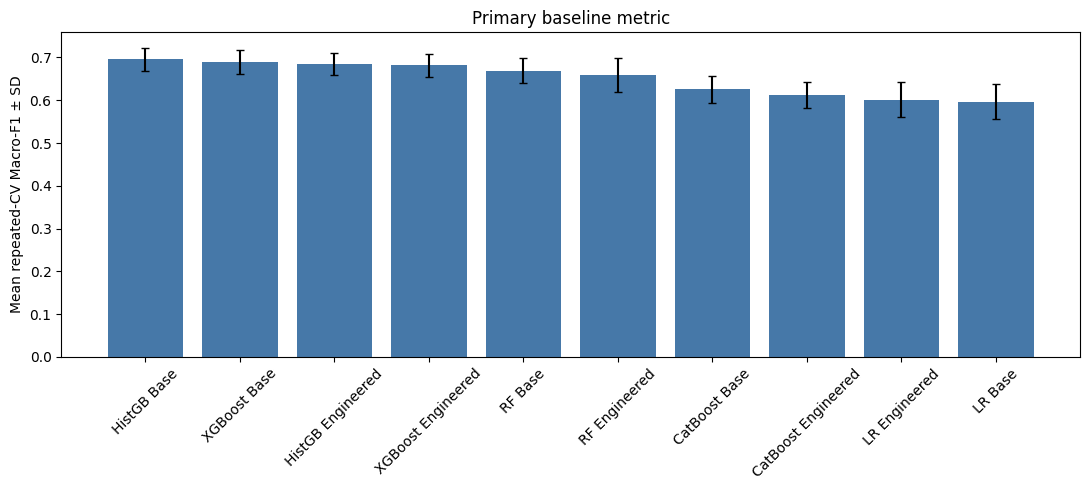

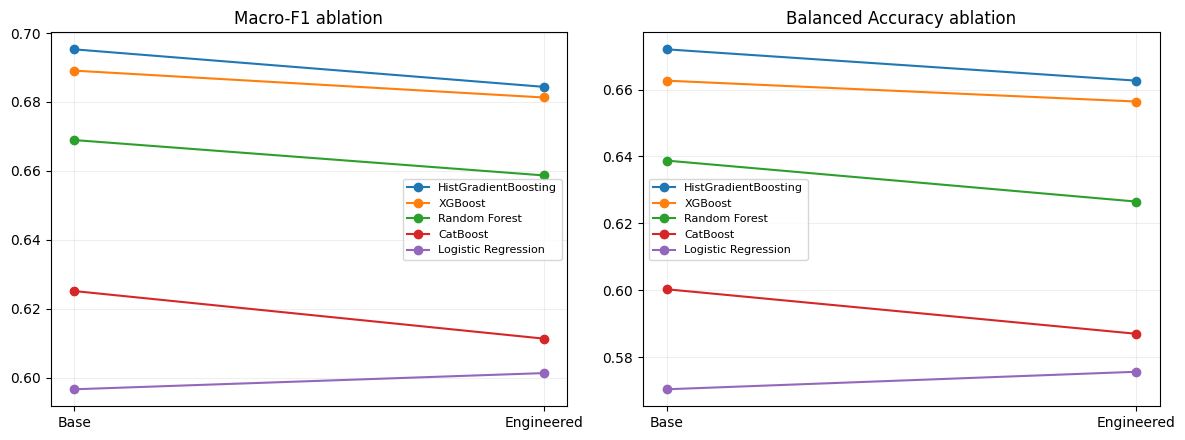

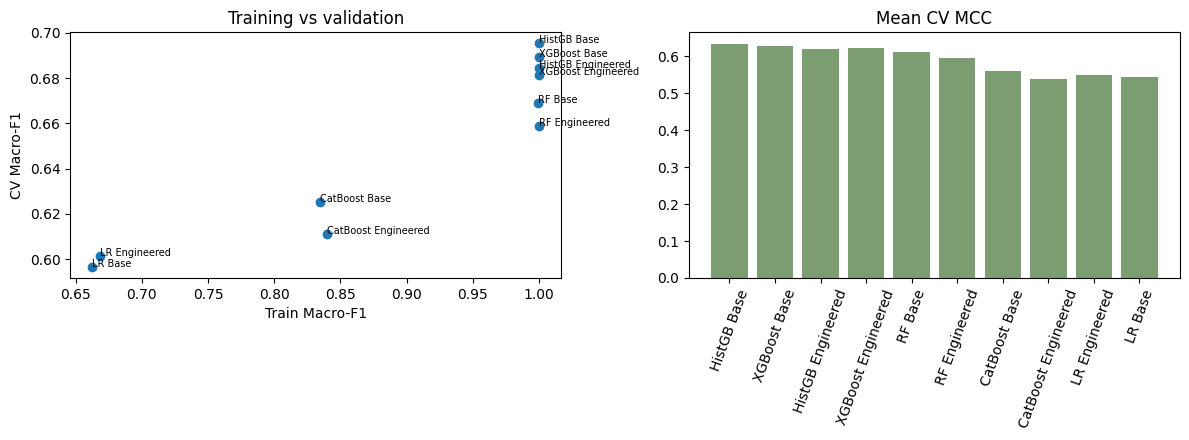

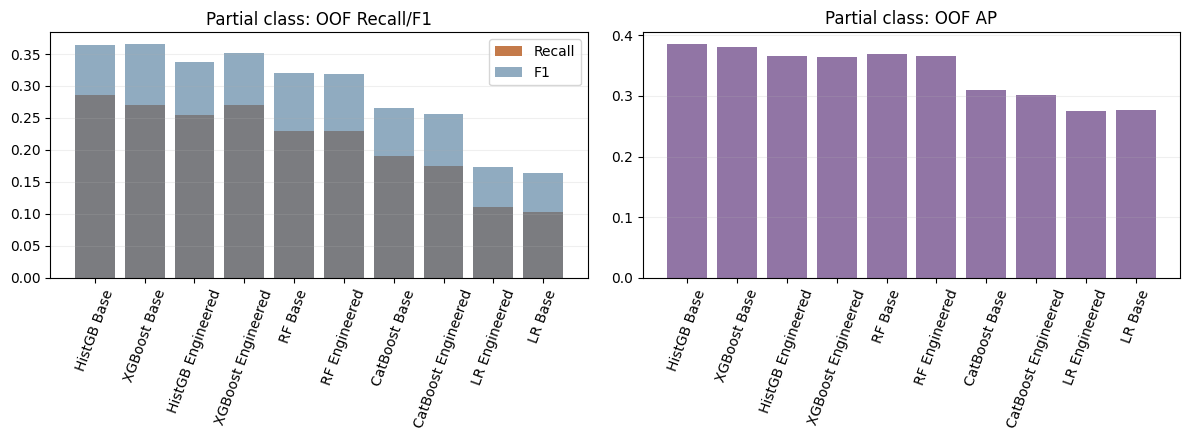

In [19]:
fig,ax=plt.subplots(figsize=(11,5));ax.bar(cv_summary.configuration,cv_summary.mean_macro_f1,yerr=cv_summary.sd_macro_f1,capsize=3,color="#4678a8")
ax.set_ylabel("Mean repeated-CV Macro-F1 ± SD");ax.set_title("Primary baseline metric");ax.tick_params(axis="x",rotation=45);fig.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for family,b in cv_summary.groupby("model_family",sort=False):
 b=b.sort_values("engineered_features");axes[0].plot(["Base","Engineered"],b.mean_macro_f1,marker="o",label=family);axes[1].plot(["Base","Engineered"],b.mean_balanced_accuracy,marker="o",label=family)
axes[0].set_title("Macro-F1 ablation");axes[1].set_title("Balanced Accuracy ablation")
for ax in axes:ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.tight_layout();plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4.5));axes[0].scatter(cv_summary.mean_train_macro_f1,cv_summary.mean_macro_f1)
for _,r in cv_summary.iterrows():axes[0].annotate(r.configuration,(r.mean_train_macro_f1,r.mean_macro_f1),fontsize=7)
axes[0].set_xlabel("Train Macro-F1");axes[0].set_ylabel("CV Macro-F1");axes[0].set_title("Training vs validation")
axes[1].bar(cv_summary.configuration,cv_summary.mean_mcc,color="#7c9d72");axes[1].set_title("Mean CV MCC");axes[1].tick_params(axis="x",rotation=70)
fig.tight_layout();plt.show()
partial=oof_class_metrics[oof_class_metrics["class"]=="Partially functional"].set_index("configuration").loc[cv_summary.configuration].reset_index()
fig,axes=plt.subplots(1,2,figsize=(12,4.5));axes[0].bar(partial.configuration,partial.recall,label="Recall",color="#c47a4a");axes[0].bar(partial.configuration,partial.f1,label="F1",alpha=.65,color="#557e9e");axes[0].set_title("Partial class: OOF Recall/F1");axes[0].legend()
axes[1].bar(partial.configuration,partial.average_precision,color="#9175a5");axes[1].set_title("Partial class: OOF AP")
for ax in axes:ax.tick_params(axis="x",rotation=70);ax.grid(axis="y",alpha=.2)
fig.tight_layout();plt.show()

# 21. Confusion Matrices and Precision-Recall Curves

Winner matrices show normalized error proportions for all families; shortlisted matrices show both counts and row-normalized rates. OOF precision-recall curves focus on the two non-majority classes. All axes use class names in the fixed display order.

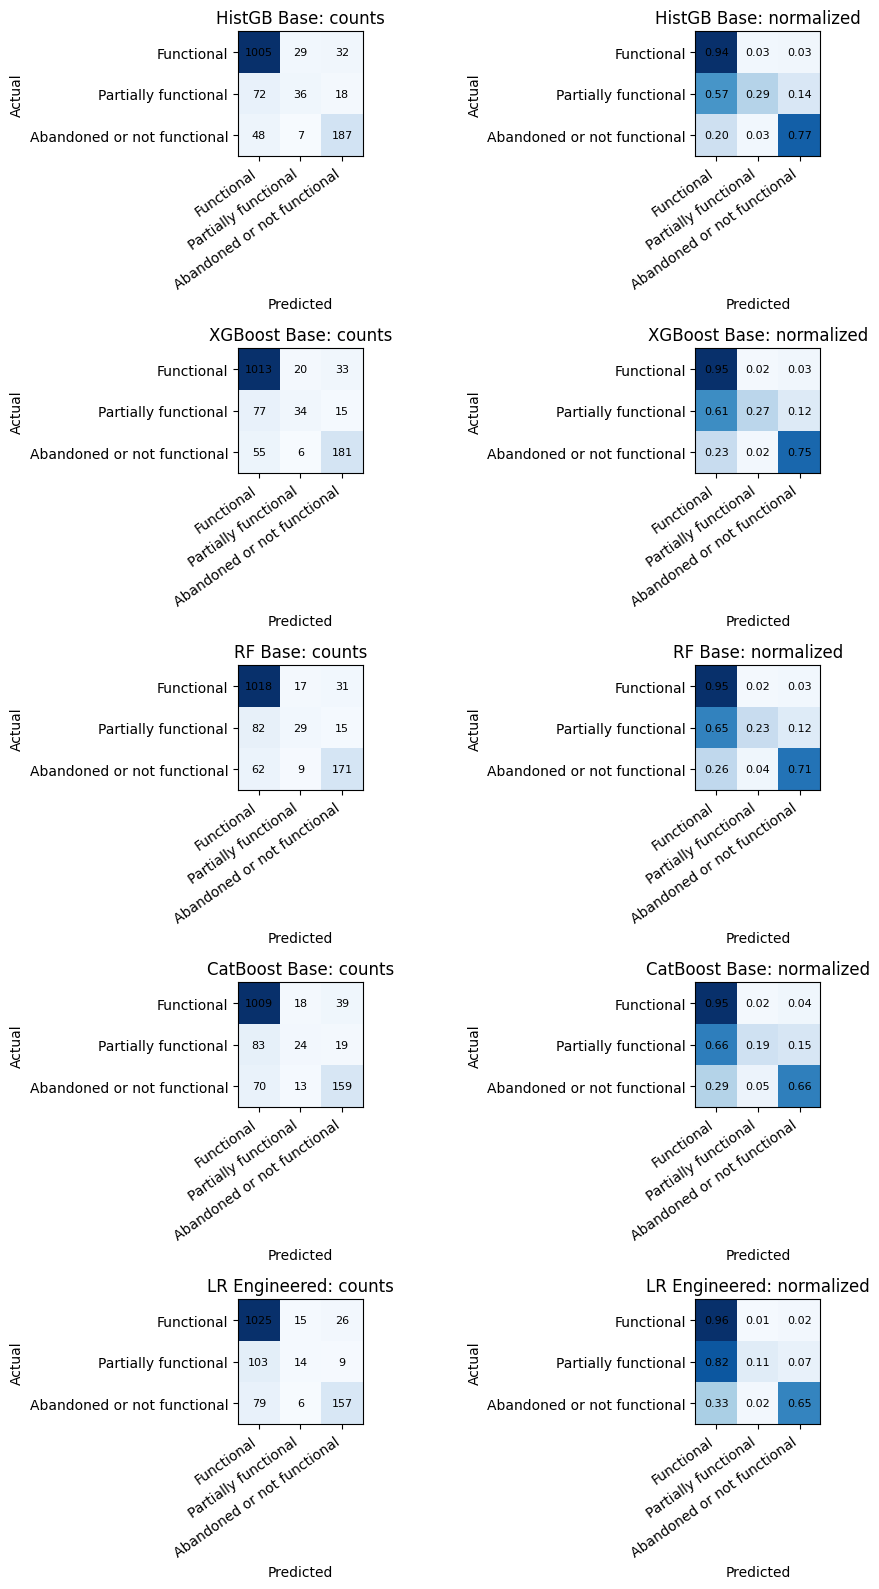

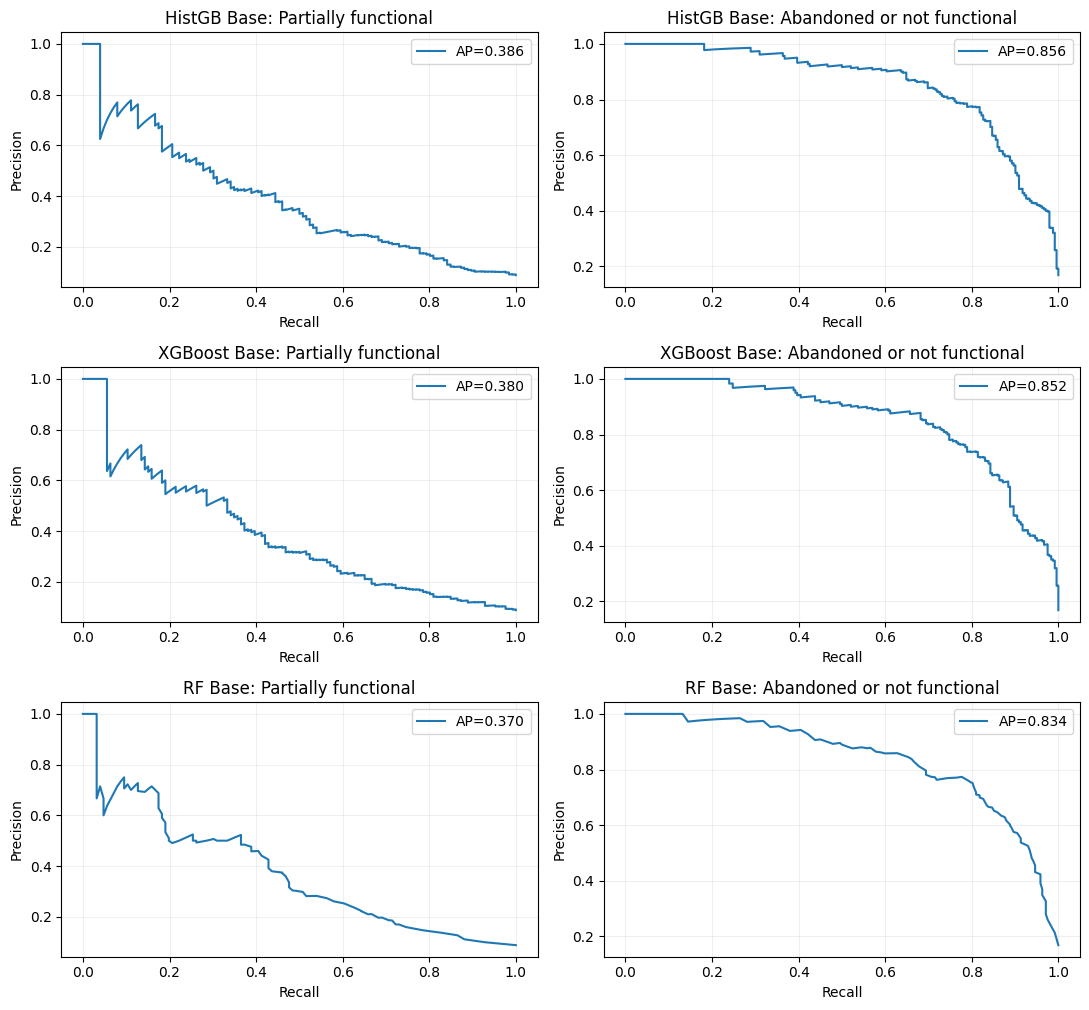

In [20]:
fig,axes=plt.subplots(len(family_winners),2,figsize=(10,3.2*len(family_winners)))
for i,row in family_winners.iterrows():
 cm=oof_confusions[row.configuration];norm=cm/cm.sum(axis=1,keepdims=True)
 for j,matrix in enumerate([cm,norm]):
  ax=axes[i,j];ax.imshow(matrix,cmap="Blues",vmin=0)
  for (r,c),v in np.ndenumerate(matrix):ax.text(c,r,f"{v:.2f}" if j else f"{int(v)}",ha="center",va="center",fontsize=8)
  ax.set_xticks(range(3),CLASS_ORDER,rotation=35,ha="right");ax.set_yticks(range(3),CLASS_ORDER);ax.set_xlabel("Predicted");ax.set_ylabel("Actual");ax.set_title(f"{row.configuration}: {'normalized' if j else 'counts'}")
fig.tight_layout();plt.show()
fig,axes=plt.subplots(len(shortlisted),2,figsize=(11,3.4*len(shortlisted)),squeeze=False)
for i,name in enumerate(shortlisted):
 sub=oof_predictions[oof_predictions.configuration==name];truth=np.array([CLASS_TO_ID[x] for x in sub.true_class])
 for j,cid in enumerate([1,2]):
  binary=(truth==cid).astype(int);score=sub[f"probability_{ID_TO_CLASS[cid]}"].to_numpy();p,r,_=precision_recall_curve(binary,score);ap=average_precision_score(binary,score)
  axes[i,j].plot(r,p,label=f"AP={ap:.3f}");axes[i,j].set_title(f"{name}: {ID_TO_CLASS[cid]}");axes[i,j].set_xlabel("Recall");axes[i,j].set_ylabel("Precision");axes[i,j].legend();axes[i,j].grid(alpha=.2)
fig.tight_layout();plt.show()

# 22. Results Interpretation

Observations are generated from the measured results. Macro-F1 leads; supporting metrics describe minority performance, probabilities, stability, and train-CV gaps. Small differences relative to variability are uncertain and should not be overstated.

In [21]:
top=cv_summary.iloc[0];stable=cv_summary.sort_values("sd_macro_f1").iloc[0];gap=cv_summary.sort_values("mean_train_cv_gap",ascending=False).iloc[0];mcc=cv_summary.sort_values("mean_mcc",ascending=False).iloc[0];ll=cv_summary.sort_values("mean_log_loss").iloc[0]
partial_f1=max(oof_by,key=lambda c:oof_by[c]["partial_f1"]);partial_recall=max(oof_by,key=lambda c:oof_by[c]["partial_recall"]);partial_ap=max(oof_by,key=lambda c:oof_by[c]["partial_ap"])
print(f"Highest mean CV Macro-F1: {top.configuration} {top.mean_macro_f1:.4f} ± {top.sd_macro_f1:.4f}.")
print(f"Most stable by SD: {stable.configuration} (SD {stable.sd_macro_f1:.4f}); largest train-CV gap: {gap.configuration} ({gap.mean_train_cv_gap:.4f}).")
print(f"Highest mean MCC: {mcc.configuration} ({mcc.mean_mcc:.4f}); lowest Log Loss: {ll.configuration} ({ll.mean_log_loss:.4f}).")
print("Best OOF Partial F1/Recall/AP:",partial_f1,partial_recall,partial_ap)
for _,r in feature_ablation.iterrows():print(f"{r.model_family}: engineered Macro-F1 change {r.macro_f1_difference:+.4f}.")

Highest mean CV Macro-F1: HistGB Base 0.6953 ± 0.0274.
Most stable by SD: HistGB Engineered (SD 0.0256); largest train-CV gap: RF Engineered (0.3411).
Highest mean MCC: HistGB Base (0.6332); lowest Log Loss: CatBoost Base (0.4539).
Best OOF Partial F1/Recall/AP: XGBoost Base HistGB Base HistGB Base
HistGradientBoosting: engineered Macro-F1 change -0.0109.
XGBoost: engineered Macro-F1 change -0.0078.
Random Forest: engineered Macro-F1 change -0.0103.
CatBoost: engineered Macro-F1 change -0.0138.
Logistic Regression: engineered Macro-F1 change +0.0047.


# 23. Imbalance Policy for Notebook 05

These Stage-6 baselines use no resampling or class/sample weighting. The Partially functional class remains difficult: even the best shortlisted OOF recall is 0.2857. Notebook 05 should compare imbalance treatment in a controlled order: (A) optimized model without treatment, (B) class or sample weighting, (C) `RandomOverSampler`, then (D) `SMOTENC` when a suitable mixed categorical/numeric representation is available. Use training-fold class frequencies to calculate any weights. For multiclass XGBoost, evaluate per-sample weights rather than treating binary `scale_pos_weight` as a complete solution. Random Forest can compare `None`, `balanced`, and where appropriate `balanced_subsample`; HistGradientBoosting can receive fold-derived sample weights if its fitted API supports them; CatBoost may test `auto_class_weights="Balanced"` in its smaller challenger study.

Any resampling and supervised feature selection must occur *inside each training fold* in a pipeline, leaving every validation fold untouched. `RandomOverSampler` provides a simple reference. Ordinary SMOTE after one-hot encoding can synthesize fractional indicator columns, so any synthetic resampling should use `SMOTENC` with a technically appropriate mixed representation in an imbalanced-learn pipeline. None of these treatments is assumed to improve validation performance. The locked holdout is inaccessible during these comparisons.


# 24. Notebook 05 Optimization Handoff

**Objective and validation.** Improve repeated-CV Macro-F1 while preserving leakage-safe validation. Track Partially functional Recall, F1, and Average Precision; Balanced Accuracy, Macro Recall/Precision, MCC, Weighted F1, and Accuracy; Log Loss and macro AP; training Macro-F1, CV SD, and the train-to-CV gap. Keep unseen-country performance as a secondary diagnostic. A smaller stratified five-fold search followed by 5×3 repeated-CV evaluation of finalists is a reasonable cost-conscious design. Prefer an efficient, reproducible search such as `RandomizedSearchCV` when the search space is large; choose the method based on the experiment, without an invented target score or arbitrary composite. Lock preprocessing, imbalance treatment, hyperparameters, and final model choice before the holdout is accessed.

**Primary shortlist from Stage 6.** HistGradientBoosting Base led mean CV Macro-F1 (0.6953), Balanced Accuracy (0.6720), and shortlisted Partial Recall/AP (0.2857/0.3855), with a 0.3047 train-to-CV gap. Investigate `learning_rate`, `max_iter`, `max_leaf_nodes`, `max_depth`, `min_samples_leaf`, and `l2_regularization` to control excessive fit while preserving or improving validation performance and Partial-class behavior. XGBoost Base was close on Macro-F1 (0.6891; CV SD 0.0283), had strong MCC (0.6285), the highest shortlisted Partial F1 (0.3656), and lower Log Loss (0.5202) than HistGB or RF. Investigate `n_estimators` with `learning_rate` for boosting capacity/speed; `max_depth` with `min_child_weight` for tree complexity; `subsample` and `colsample_bytree` for row/feature sampling; `gamma` for minimum split gain; and `reg_alpha`/`reg_lambda` for L1/L2 regularization. Random Forest Base had lower random-CV Macro-F1 (0.6689) but the strongest mean observed-class score in the nine-country diagnostic (0.4897); it is a useful bagging comparison. Its 0.3307 train-to-CV gap warrants testing `n_estimators`, shallower `max_depth`, `max_features`, larger `min_samples_split`/`min_samples_leaf`, `bootstrap`, and fold-local `class_weight`. A lower training score or narrower gap alone does not establish a better model; validation performance remains primary.

**Secondary challenger.** CatBoost Base trailed the top three on Macro-F1 (0.6251), but had the lowest baseline Log Loss (0.4539), native categorical handling, and a fixed 100-iteration Stage-6 runtime cap. A smaller targeted study can test `iterations`, `depth`, `learning_rate`, `l2_leaf_reg`, and class weighting to see whether it closes the classification gap. This does not promote CatBoost into the primary three-family search.

**Preprocessing scope.** Start the primary searches from base representations because engineering reduced Macro-F1 for HistGB, XGBoost, and RF in Stage 6. A small ablation can revisit base versus engineered features and one-hot rare-category thresholds of 5, 10, and 20. Test selected engineered subsets or supervised selection (for example, mutual information or model-based selection) only if justified, with every fit inside CV. Continue to inspect probability quality and country robustness separately from the primary ranking. The baseline evidence leaves room to improve minority recognition and generalization; Notebook 04 neither tunes models nor selects a final one.


In [22]:
TUNING_PLAN={"Logistic Regression":["C","valid penalty/solver","class weights"],"Random Forest":["n_estimators","max_depth","min_samples_split","min_samples_leaf","max_features","bootstrap","class_weight"],"HistGradientBoosting":["learning_rate","max_iter","max_leaf_nodes","max_depth","min_samples_leaf","l2_regularization"],"XGBoost":["n_estimators","learning_rate","max_depth","min_child_weight","subsample","colsample_bytree","gamma","reg_alpha","reg_lambda"],"CatBoost":["iterations","depth","learning_rate","l2_leaf_reg","random_strength","bagging_temperature","class weights / auto_class_weights"]}
print(json.dumps({family:TUNING_PLAN[family] for family in shortlist.model_family},indent=2))


{
  "HistGradientBoosting": [
    "learning_rate",
    "max_iter",
    "max_leaf_nodes",
    "max_depth",
    "min_samples_leaf",
    "l2_regularization"
  ],
  "XGBoost": [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "gamma",
    "reg_alpha",
    "reg_lambda"
  ],
  "Random Forest": [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
    "class weights"
  ]
}


# 25. Persist Experiment Evidence

Save CV folds, summary, OOF predictions and class metrics, ablation, family winners, country diagnostic, warning log, and a data-derived Notebook 05 shortlist. These are development experiment outputs only; no model artifact or holdout prediction is saved.

In [23]:
RESULTS_DIR=Path("../reports/model_development");RESULTS_DIR.mkdir(parents=True,exist_ok=True)
fold_results.to_csv(RESULTS_DIR/"baseline_cv_folds.csv",index=False)
cv_summary.to_csv(RESULTS_DIR/"baseline_cv_summary.csv",index=False)
oof_predictions.to_csv(RESULTS_DIR/"oof_predictions.csv",index=False)
oof_class_metrics.to_csv(RESULTS_DIR/"oof_class_metrics.csv",index=False)
oof_class_metrics[["configuration","class","average_precision"]].to_csv(RESULTS_DIR/"oof_average_precision.csv",index=False)
feature_ablation.to_csv(RESULTS_DIR/"feature_ablation_summary.csv",index=False)
family_winners.to_csv(RESULTS_DIR/"model_family_winners.csv",index=False)
country_robustness.to_csv(RESULTS_DIR/"country_robustness.csv",index=False)
pd.DataFrame(warning_records,columns=["configuration","repeat","fold","category","message"]).to_csv(RESULTS_DIR/"model_warnings.csv",index=False)
shortlist_json={"primary_metric":"Mean repeated-stratified-CV Macro-F1",
 "validation_strategy":{"name":"RepeatedStratifiedKFold","n_splits":5,"n_repeats":3,"random_state":42},
 "shortlisted_model_families":shortlist.model_family.tolist(),"selected_baseline_variant_per_family":[],"locked_holdout_loaded":False}
for _,r in shortlist.iterrows():
 m=oof_by[r.configuration];country=country_robustness[country_robustness.configuration==r.configuration]
 shortlist_json["selected_baseline_variant_per_family"].append({"model_family":r.model_family,"configuration":r.configuration,
  "preprocessing_variant":r.preprocessing_variant,"cv_macro_f1":float(r.mean_macro_f1),"cv_sd":float(r.sd_macro_f1),
  "balanced_accuracy":float(r.balanced_accuracy),"mcc":float(r.mcc),"partial_f1":m["partial_f1"],
  "partial_recall":m["partial_recall"],"partial_ap":m["partial_ap"],"train_cv_gap":float(r.train_cv_gap),
  "mean_log_loss":float(r.log_loss),"country_macro_f1_mean_observed_classes":float(country.macro_f1_observed_classes.mean())})
(RESULTS_DIR/"notebook04_shortlist.json").write_text(json.dumps(shortlist_json,indent=2)+"\n",encoding="utf-8")
print("Saved development-only experiment evidence in",RESULTS_DIR)

Saved development-only experiment evidence in ..\reports\model_development


# 26. No Holdout Access and Source Check

Notebook 04 uses only the 1,434-row development set. The locked holdout was not loaded or evaluated. The source assertion scans executable cells preceding itself for holdout filenames and confirms the development shape.

In [24]:
notebook_source=json.loads(Path("04_model_development.ipynb").read_text(encoding="utf-8"))
source_cell=next(i for i,c in enumerate(notebook_source["cells"]) if c["cell_type"]=="code" and "source_cell" in "".join(c["source"]))
code_before="\n".join("".join(c["source"]) for c in notebook_source["cells"][:source_cell] if c["cell_type"]=="code")
forbidden=["X_test_"+"raw.csv","y_test"+".csv"]
assert all(filename not in code_before for filename in forbidden)
assert X_train.shape==(1434,32) and len(y)==1434
assert "X_test" not in globals() and "y_test" not in globals()
print("Notebook 04 used only the 1,434-row development set. The locked holdout was not loaded or evaluated.")

Notebook 04 used only the 1,434-row development set. The locked holdout was not loaded or evaluated.


# 27. Stage 6 Summary

Five model families and ten baseline configurations completed 5×3 repeated stratified CV, fixed five-fold OOF diagnostics, feature ablation, train-to-CV comparisons, and a secondary country diagnostic. HistGB Base led mean CV Macro-F1 (0.6953); XGBoost Base was close relative to their fold variability (0.6891, CV SD 0.0283). RF Base scored lower in random CV (0.6689) but higher on mean observed-class Macro-F1 in the unseen-country diagnostic (0.4897) than the other shortlisted variants. The Partially functional class remains difficult: shortlisted OOF recall ranges from 0.2302 to 0.2857. HistGB, XGBoost, and RF all have near-perfect training Macro-F1 and train-to-CV gaps above 0.30. Engineered features reduced primary CV Macro-F1 for all three. No imbalance correction, hyperparameter tuning, or holdout evaluation has occurred. These baselines support targeted Notebook 05 optimization for minority recognition and generalization; they do not establish a final model.


In [25]:
assert fold_results.configuration.nunique()==10 and fold_results.groupby("configuration").size().eq(15).all()
assert len(oof_predictions)==10*1434 and len(family_winners)==5 and len(shortlist)==3
assert set(cv_summary.model_family)==set(["Logistic Regression","Random Forest","HistGradientBoosting","XGBoost","CatBoost"])
assert "X_test" not in globals() and "y_test" not in globals()
print("Repeated-CV fits:",len(fold_results),"| OOF predictions:",len(oof_predictions),"| validations/configuration: 15")
print("Shortlist:",shortlisted)
print("Warnings recorded:",len(warning_records))
print("Resampling: no | class weights: no | tuning: no | holdout evaluation: no")
print("Stage 6 baseline comparison complete; no final model selected.")

Repeated-CV fits: 150 | OOF predictions: 14340 | validations/configuration: 15
Shortlist: ['HistGB Base', 'XGBoost Base', 'RF Base']
Warnings recorded: 0
Resampling: no | class weights: no | tuning: no | holdout evaluation: no
Stage 6 baseline comparison complete; no final model selected.
